# ENGR 1451/2451 — Weekly Assignment 2
**10 points**

This assignment applies the descriptive-statistics and visual-exploration methods introduced in the W02A lab notebooks: center and spread, quartiles and outliers, histograms and boxplots, grouped summaries, and the importance of pairing numerical summaries with visualizations.


 **Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

Put `iris.csv` in a folder named `data` next to this notebook so that the path below works.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

iris = pd.read_csv(Path("./data/iris.csv"))
iris.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

Consider the following measurements:

\[
x = [4,\ 6,\ 8,\ 10,\ 12].
\]

Create two transformed versions:

- **shifted:** \(x + 7\)
- **scaled:** \(3x\)

### A. Predict first (1 pt)

Without calculating, predict what happens to the **mean**, **median**, **sample standard deviation**, and **IQR** after each transformation.

Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | Increases by 7 | Multiplies by 3 |
| Median | Increases by 7 | Multiplies by 3 |
| Sample standard deviation | Unchanged | Multiplied by 3 |
| IQR | Unchanged | Multiplied by 3 |


**Answer:**

### B. Verify with Python (1.5 pts)

Create a small summary table for the original, shifted, and scaled data containing:

- mean;
- median;
- sample standard deviation; and
- IQR.

Then state whether the results agree with your predictions.



In [4]:
x = pd.Series([4, 6, 8, 10, 12], name="original")
shifted = x + 7
scaled = 3 * x

# IQR function to return IQR
def iqr(series):
    return series.quantile(.75) - series.quantile(.25)

# Creating a summary table dataframe for easy data visualization
summary_table = pd.DataFrame({"Data" : ["regular","shifted","scaled"]
                              ,"Mean" : [x.mean(), shifted.mean(), scaled.mean()]
                              , "Median" : [x.median(), shifted.median(), scaled.median()]
                              , "Sample STD" : [x.std(), shifted.std(), scaled.median()]
                              , "IQR" : [iqr(x), iqr(shifted), iqr(scaled)] })
summary_table.head()

,Data,Mean,Median,Sample STD,IQR
0,regular,8.0,8.0,3.162278,4.0
1,shifted,15.0,15.0,3.162278,4.0
2,scaled,24.0,24.0,24.000000,12.0


**Answer:** My predictions were the same as what is found with my above code.


## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use the Iris variable `sepal.width`.

1. Calculate \(Q_1\), the median, and \(Q_3\).
2. Calculate the IQR.
3. Calculate the lower and upper Tukey fences:
   \[
   Q_1 - 1.5\,\mathrm{IQR}
   \qquad\text{and}\qquad
   Q_3 + 1.5\,\mathrm{IQR}.
   \]
4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.
5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.


In [5]:
sepal_width = iris["sepal.width"]
import numpy as np

# 1. Calculate Q1 and Q3
Q_1 = sepal_width.quantile(.25)
Q_3 = sepal_width.quantile(.75)

# 2. Calculate IQR
iqr = Q_3 - Q_1

# 3. Calculate fences
lower_fence = Q_1 - 1.5*iqr
upper_fence = Q_3 + 1.5*iqr

# 4. Get outliers using fences
outliers = sepal_width[(sepal_width > upper_fence) | (sepal_width < lower_fence)]

# 5. Print number of outliers and display outliers
print(f'Number of outliers: {len(outliers)}')
print(outliers)

Number of outliers: 4
15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal.width, dtype: float64


**Answer:**
There were 4 outliers, they were mixed, 3 were high and 1 was low.

## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use `sepal.length` for all parts below.

### A. Histograms and bin choice (1.5 pts)

Create two histograms of the **same** `sepal.length` data:
- one using **6 bins**;
- one using **18 bins**.

Give each plot meaningful axis labels and a title. Then explain briefly:
1. what features of the distribution appear in both histograms; and
2. what changes when the number of bins changes.


<Axes: >

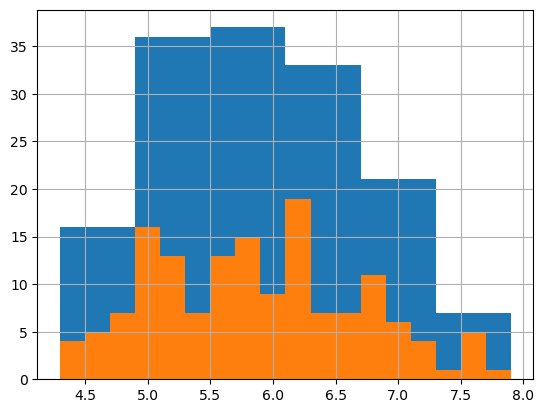

In [4]:
# Your histogram code here

# Pull sepal length
sepal_length = iris["sepal.length"]

# Create histograms
sepal_length.hist(bins=6)
sepal_length.hist(bins=18)

**Answer:**
1. Though the specific distribution looks different between the two bin counts, there is still a higher presence toward the middle of the plot, with a slight right tail on both plots.
2. Something that changed between the bin sizes is the distribution, the lower bin count looks more like a normal data distribution than the high bin count. The number of observations per bin also goes down when bin count goes up.

### B. Grouped numerical summary (1 pt)

Calculate the `count`, `median`, sample `std`, `min`, and `max` of `sepal.length` for each Iris species using `groupby()` and `agg()`.

Which species has the largest median `sepal.length`? Which has the largest sample standard deviation?


In [5]:
# Useful pattern:
# iris.groupby("variety")["sepal.length"].agg([...])

# Create aggregate value table
iris.groupby("variety")["sepal.length"].agg(["count","median","std","min","max"])

,count,median,std,min,max
variety,,,,,
Setosa,50,5.0,0.352490,4.3,5.8
Versicolor,50,5.9,0.516171,4.9,7.0
Virginica,50,6.5,0.635880,4.9,7.9


**Answer:**
Virginica has the larget median sepal.length, and Virginica also has the highest standard deviation.

### C. Boxplot by species (1.5 pts)

Create a boxplot of `sepal.length` grouped by `variety`.

Give the plot a clear title and axis labels. Then state **two conclusions** supported by the boxplot: one about differences in center and one about differences in spread or overlap among the species.


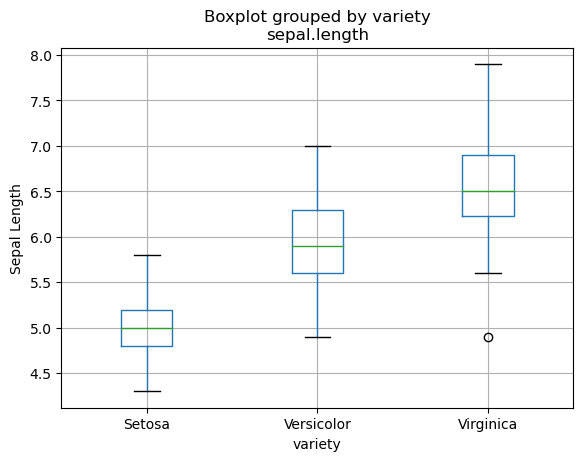

In [6]:
# Useful pattern:
# iris.boxplot(column="...", by="...")

# Create grouped boxplots on the same plot
boxplot = iris.boxplot(column="sepal.length", by="variety")

# Set Y label
boxplot.set_ylabel("Sepal Length")

plt.show()

**Answer:**
Virginica has the widest spread, and the most outliers as supported by the dot. The centers range from 5 to 6.5, and each variety is centered around a different point. The medians go Setosa, Versicolor, Virginica in least to greatest order.

## LE2-4. Similar summaries can hide different distributions (2 pts)

The two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.

### A. Compare numerical summaries (0.75 pt)

For datasets A and B, calculate the:
- mean;
- median; and
- sample standard deviation.

Confirm that these three numerical summaries are the same (or equal to rounding).


In [7]:
comparison = pd.DataFrame(
    {
        "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
    }
)

# Useful pattern:
# comparison.agg(["mean", "median", "std"])
# Your code here

# Get summary values
summary = comparison.agg(["mean","median","std"])

# Compare summary values
print(summary["A"] == summary["B"])

mean      True
median    True
std       True
dtype: bool


### B. Visualize the distributions (0.75 pt)

Choose **one** of the following ways to compare datasets A and B:
- histograms using the same bins and x-axis scale; or
- boxplots shown on the same figure.

Give the visualization a clear title and meaningful axis labels.


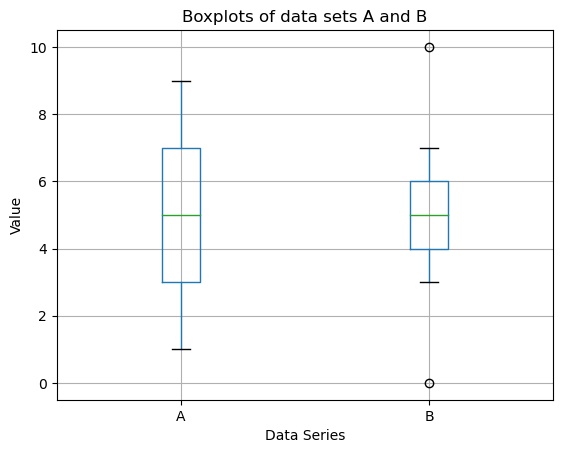

In [8]:
# Your visualization code here

# Create boxplot
boxplot = comparison.boxplot()

# Create title
plt.title("Boxplots of data sets A and B")

# Set axes labels
boxplot.set_xlabel("Data Series")
boxplot.set_ylabel("Value")

plt.show()

### C. Interpret (0.5 pt)

What important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?

In one or two sentences, explain why numerical summaries and visualizations should be used together.

**Answer:**

The bulk of dataset A is wider than the bulk of dataset B, but B has outliers that mask mean. The median is the same across both datasets.
Numerical values must be accompanied by data visualization, as two datasets with the exact same means, medians, etc. can look very different. The summaries alone are not enough to describe these datasets as different.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 1,
  "session_date": "2026-09-15",
  "messages": [
    {"i": 1, "who": "student", "text": "remind me how to select certain parts of a dataframe column in pandas with a condiional"},
    {"i": 2, "who": "tutor", "text": "Explained boolean masking on a Series: comparisons return a mask, mask used in [] to select rows, combining conditions needs & / | with parentheses, df[df[\"col\"] > 10] filters rows. [trimmed]"},
    {"i": 3, "who": "student", "text": "how to go to a numpy array"},
    {"i": 4, "who": "tutor", "text": "Explained .to_numpy() and .values to convert Series/DataFrame to array, noted ddof difference still applies after conversion. [trimmed]"},
    {"i": 5, "who": "student", "text": "how cna i drop the index column on a selection fo a dataframe"},
    {"i": 6, "who": "tutor", "text": "Explained .reset_index(drop=True) to renumber index, to_string(index=False) for cosmetic display, set_index for relabeling. [trimmed]"},
    {"i": 7, "who": "student", "text": "i dont want an index column"},
    {"i": 8, "who": "tutor", "text": "Clarified pandas always has an index; explained print(df.to_string(index=False)) and df.style.hide(axis=\"index\") for display, and set_index as an alternative for meaningful row labels. [trimmed]"},
    {"i": 9, "who": "student", "text": "remind me how vectorized conditionals wotk with numpy arrays"},
    {"i": 10, "who": "tutor", "text": "Explained array comparisons return boolean arrays, boolean indexing to select elements, & / | with parentheses for combining conditions, and np.where() for labeling. [trimmed]"},
    {"i": 11, "who": "student", "text": ".hist syntax for pandas"},
    {"i": 12, "who": "tutor", "text": "Explained Series.hist(bins=...), DataFrame.hist(), plt.hist() as alternative, adding labels/title afterward, and the need for plt.show()/plt.figure() to keep two histograms separate. [trimmed]"},
    {"i": 13, "who": "student", "text": "how to set figure title and axis labels for a dataframe.boxplot object"},
    {"i": 14, "who": "tutor", "text": "Explained df.boxplot(column=, by=) syntax, the automatic suptitle quirk when using by=, and the plt.suptitle(\"\") fix combined with ax.set_xlabel()/ax.set_ylabel(). [trimmed]"},
    {"i": 15, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 2, "part": null, "type": "explain"},
    {"i": 4, "part": null, "type": "explain"},
    {"i": 6, "part": null, "type": "explain"},
    {"i": 8, "part": null, "type": "explain"},
    {"i": 10, "part": null, "type": "explain"},
    {"i": 12, "part": "2-3A", "type": "explain"},
    {"i": 14, "part": "2-3C", "type": "explain"}
  ],
  "parts": [],
  "tutor_assessment": [
    "No assignment-specific code was submitted this session; the student asked a string of free-standing Python/pandas questions (masking, array conversion, index handling, .hist syntax, boxplot titling) likely in preparation for LE2-2 and LE2-3A/C, but never pasted a working cell.",
    "No unstuck or release-valve use occurred; nothing to flag as a tutoring gap."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
